In [1]:

import numpy as np
import matplotlib.pyplot as plt
import scipy.io as scipi
import pandas as pd
import os as os
import seaborn as sns
import scipy.optimize 
import scipy.stats as st
import tkinter as tk
from scipy.signal import savgol_filter
import warnings
from scipy.stats import sem, wilcoxon,mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
import statsmodels.api as sm
from statsmodels.formula.api import ols
from matplotlib import rcParams


warnings.filterwarnings("ignore")

pathroot =r'D:\DATA\DATA_UZ' 
pathfile= r'D:\DATA_UZ_DATASAVED'

pathroot =r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA_LINUX_SHARED/DATA_UZ'
pathfile= r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATASAVED'

saving_dir=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA_LINUX_SHARED/DATA_UZ/figures'



print(pathroot)
os.chdir(pathroot)
cwd = os.getcwd()
print(cwd)

df=pd.read_csv(os.path.join(pathroot,'DataframeNCUZUpdated160724.csv'),delimiter=';')
LfpPop=np.load(os.path.join(pathroot,'LfpPop.npy'),allow_pickle=True)




mappingelectrode=[[11 ,4  ,8 ,13, 10,  6,  9 ,12], [14 , 1  ,2  ,3 ,15  ,5  ,0,  7], [30 ,22 ,28 ,29, 26, 27 ,24 ,31], [25 ,16, 20, 18, 23, 17 ,19 ,21]]

valid=np.ones((390,1))
df['Valid']=valid
DFDATA=df
mappingelectrode


columns = list(DFDATA.columns)
columns.remove('NewFileName')
columns.insert(0, 'NewFileName')
DFDATA = DFDATA[columns]

# Forcer l'utilisation du texte en tant que texte dans SVG
# Forcer l'utilisation du texte en tant que texte dans SVG



colors = {'#2a7e19', '#A8E5A0'}
colorborder='k'

plt.rcParams.update({
    'axes.labelsize': 16,   # Taille des labels des axes
    'xtick.labelsize': 16,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 16,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 16,   # Taille de la police de la légende
    'axes.titlesize': 16,   # Taille du titre
    'axes.labelcolor': 'k',  # Couleur des labels
    'xtick.color': 'k',      # Couleur des ticks

})

rcParams['svg.fonttype'] = 'path'
rcParams['font.family'] = 'DejaVu Sans'


/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA_LINUX_SHARED/DATA_UZ
/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA_LINUX_SHARED/DATA_UZ


## Figure 1B LFP

     NewFileName  ArrayId        Date Stim Therm   Side Line DayP  Anesthesie  \
111          112       12  2024.02.06  Tac  none  Wcont   WT   P8           0   

     CSF  Deep                    FileName                           CodeName  \
111    0   407  allego_0__uid0206-13-23-30  Tac_Wcont_WT_P8_F_4.7g_Buz32_Z407   

     Valid  
111    1.0  


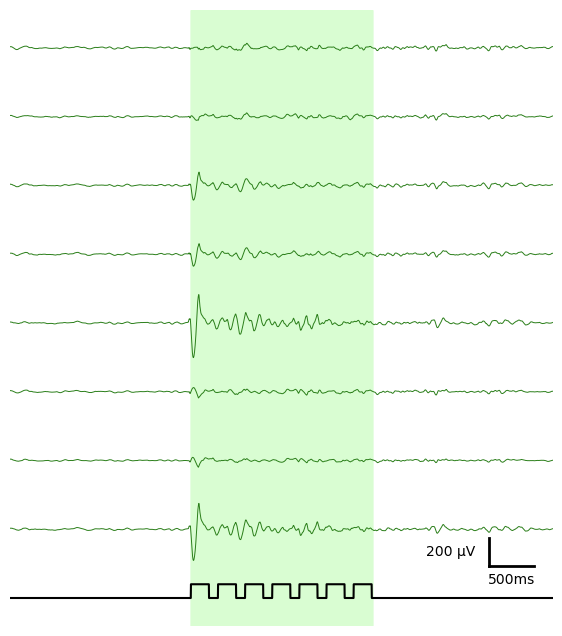

In [2]:
Newfilename=112

from scipy import stats
from matplotlib import rcParams
import warnings 

warnings.filterwarnings("ignore")


plotting_ind_channel=0

saving_dir=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA_LINUX_SHARED/DATA_UZ/figures'

MeanAUCBas=[]
MeanAUCStim=[]
Response=[]
dffile=DFDATA[DFDATA['NewFileName']==Newfilename]
print(dffile)

for ch in range(32):
   
    fileid=Newfilename-1
    lfp=LfpPop[fileid]

    lfpch=lfp[0][ch].T

    SizeLfp=np.shape(lfpch)

    derivative=np.diff(lfpch,axis=0)

    AUC=np.trapz(np.abs(derivative), axis=1)

    AUC_filt=savgol_filter(AUC, 51, 3)

    if (dffile['Stim'] == 'Tac').any:
        analysis_window=2000
    elif (dffile['Stim'] == 'Thq').any:
        if (dffile['Therm'] == 'cool').any:
            analysis_window=3900
        elif (dffile['Therm'] == 'hot').any:
            analysis_window=2200

    X=lfpch

    MeanAUCBas.append(np.mean(AUC_filt[0:analysis_window]))
    MeanAUCStim.append(np.mean(AUC_filt[10000:analysis_window+10000]))

    t_statistic, p_value = stats.ttest_rel(AUC_filt[0:analysis_window],AUC_filt[10000:analysis_window+10000],alternative='less')

    if p_value<0.05:
        ResponseCh=1
    else:
        ResponseCh=0

    Response.append(ResponseCh)

lfp=LfpPop[fileid]

fig, ax = plt.subplots(1,1, figsize=(7,8))

start_time=8000
end_time=14000
stim_start=10000
stim_end=start_time+analysis_window

choffset=0
axid=1
ayid=1
for ch in mappingelectrode[0]:
    lfpch=lfp[0][ch].T
  
    ax. plot(savgol_filter(lfpch[:,1],101,3,axis=0)+choffset, color="#2a7e19", linewidth=0.7, alpha=1)
    #ax. plot(np.mean(lfpch+choffset, axis=1), color="#2a7e19", linewidth=0.7, alpha=1)

    ax.set_xlabel('Time (ms)')
    ax.set_xticks([0, 5000, 10000, 15000, 20000])
    ax.set_xticklabels([-10, -5, 0, 5, 10])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Voltage (uV)', fontsize=12, color='k')
    ax.set_xlim(start_time,end_time)
    ax.axvspan(stim_start, stim_start+analysis_window, color='#d9fdd2', alpha=0.5, label='Tactile stim', zorder=0)

    choffset=choffset-500




y_min = -3850
y_max = -3000
origin_x = end_time - 700  # Position en X (temps)
origin_y = y_min + (y_max - y_min) * 0.1  # Position en Y (ampl
amp_y_end = origin_y + 200  # Hauteur = 50 µV
ax.plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=11)
ax.text(origin_x - 700, (origin_y + amp_y_end) / 2, "200 µV", fontsize=10, ha='left', va='center')

time_x_end = origin_x + 500  # Longueur = 1 seconde
ax.plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=11)
ax.text((origin_x + time_x_end) / 2, origin_y - 50, "500ms", fontsize=10, ha='center', va='top')



time_series = np.linspace(start_time, end_time, end_time-start_time)
pulse_series = np.zeros_like(time_series)

pulse_width = 200  
pulse_gap = 100  
num_pulses = 7     

pulse_starts = np.linspace(stim_start, stim_start + (num_pulses - 1) * (pulse_width + pulse_gap), num_pulses)

for pulse_start in pulse_starts:
    pulse_end = pulse_start + pulse_width
    pulse_indices = np.where((time_series >= pulse_start) & (time_series < pulse_end))[0]
    pulse_series[pulse_indices] = 1  

ax.plot(time_series, 100*pulse_series-4000, color='k', linewidth=1.5)

ax.axis('off')

plt.savefig(os.path.join(saving_dir, 'Figure1B_LFP.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Figure1B_LFP.svg'), format='svg', dpi=300)

In [3]:
DATA=DFDATA
DATA=DATA[DATA['ArrayId'].isin([8,9,10,12,13,14,15,16,17,22,24,29,31,32,33])]
DATA=DATA[(DATA['Stim'] == 'Tac') | (DATA['Stim'] == 'Thq')]

DATA


,NewFileName,ArrayId,Date,Stim,Therm,Side,Line,DayP,Anesthesie,CSF,Deep,FileName,CodeName,Valid
67,68,8,2024.01.30_M2,Thq,cool,Wcont,ML,P7,0,0,307,allego_5__uid0130-19-44-40,Thq_cool_Wcont_ML2_P7_M_3.7g_Buz32_Z307,1.0
68,69,8,2024.01.30_M2,Thq,hot,Wcont,ML,P7,0,0,307,allego_6__uid0130-19-56-12,Thq_hot_Wcont_ML2_P7_M_3.7g_Buz32_Z307,1.0
69,70,8,2024.01.30_M2,Thq,cool,Wcont,ML,P7,0,0,307,allego_7__uid0130-20-08-56,Thq_cool_Wcont_ML2_P7_M_3.7g_Buz32_Z307,1.0
70,71,8,2024.01.30_M2,Tac,none,Wcont,ML,P7,0,0,307,allego_8__uid0130-20-23-58,Tac_Wcont_ML2_P7_M_3.7g_Buz32_Z307,1.0
71,72,8,2024.01.30_M2,Tac,none,Wcont,ML,P7,0,0,307,allego_9__uid0130-20-34-38,Tac_Wcont_ML2_P7_M_3.7g_Buz32_Z307,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,348,33,2024.05.29,Thq,hot,Wcont,WT,P7,0,1,407,allego_6__uid0529-15-26-31,"Thq_hot_Wcont_WT_P7_F_3,9g_Buz32_Z407_ACSF37_T...",1.0
348,349,33,2024.05.29,Thq,cool,Wcont,WT,P7,0,1,407,allego_7__uid0529-15-39-59,"Thq_cool_Wcont_WT_P7_F_3,9g_Buz32_Z407_ACSF37_...",1.0
349,350,33,2024.05.29,Thq,cool,Wcont,WT,P7,0,1,407,allego_9__uid0529-15-52-58,"Thq_cool_Wcont_WT_P7_F_3,9g_Buz32_Z407_ACSF37_...",1.0
350,351,33,2024.05.29,Thq,cool,Wipsi,WT,P7,0,1,407,allego_10__uid0529-16-05-22,"Thq_cool_Wipsi_WT_P7_F_3,9g_Buz32_Z407_ACSF37_...",1.0


In [4]:
# compute AUC mean for all channel and all files !!!And generazte columns in Dataframe


from scipy import stats
from matplotlib import rcParams
import warnings 
warnings.filterwarnings("ignore")

colors = {'#2a7e19', '#A8E5A0'}
colorborder='k'
DATAALL=[]
DATAALL=pd.DataFrame(columns=['NewFileName','Date','ArrayId','Line','DayP','Stim','Therm','Side','ch','Response','MeanAUCBas','MeanAUCStim','ContrastAUC'])

for newfilename in DATA['NewFileName'].values:

    dffile=DATA[DATA['NewFileName']==newfilename]

    fileid = DATA.index[DATA['NewFileName'] == newfilename].tolist()

    MeanAUCBasch=[]
    MeanAUCStimch=[]
    Responsech=[]
    Responsefile=[]
    ContrastAUC=[]

    lfp=LfpPop[fileid[0]]
    
    if lfp[0].shape[0]<30000:

        for ch in range(32):
    

            lfpch=lfp[0][ch].T


            SizeLfp=np.shape(lfpch)

            derivative=np.diff(lfpch,axis=0)

            AUC=np.trapz(np.abs(derivative), axis=1)

            AUC_filt=savgol_filter(AUC, 101, 3)

            if (dffile['Stim'] == 'Tac').any:
                analysis_window=2000
            elif (dffile['Stim'] == 'Thq').any:
                if (dffile['Therm'] == 'cool').any:
                    analysis_window=3900
                elif (dffile['Therm'] == 'hot').any:
                    analysis_window=2200
            
            MeanAUCBasch.append(np.mean(AUC_filt[0:analysis_window]))
            MeanAUCStimch.append(np.mean(AUC_filt[10000:analysis_window+10000]))

            ContrastAUC.append((np.mean(AUC_filt[10000:analysis_window+10000])-np.mean(AUC_filt[0:analysis_window]))/(np.mean(AUC_filt[10000:analysis_window+10000])+np.mean(AUC_filt[0:analysis_window])))

            t_statistic, p_value = stats.ttest_rel(AUC_filt[0:analysis_window],AUC_filt[10000:analysis_window+10000],alternative='less')

            if p_value<0.05:
                ResponseCh=1
            else:
                ResponseCh=0

            Responsefile.append(ResponseCh)
    
        filename=[newfilename]*32
        stim=dffile['Stim'].values[0]
        therm=dffile['Therm'].values[0]
        side=dffile['Side'].values[0]
        arrayid=dffile['ArrayId'].values[0]
        linemice=dffile['Line'].values[0]
        dayP=dffile['DayP'].values[0]
        Channel=np.arange(1,33)
        Date=dffile['Date'].values[0]


        DATAch=pd.DataFrame({'NewFileName':filename,'Date':Date,'ArrayId':arrayid,'Line':linemice,'DayP':dayP,'Stim':stim,'Therm':therm,'Side':side,'ch':Channel,'Response':Responsefile,'MeanAUCBas':MeanAUCBasch,'MeanAUCStim':MeanAUCStimch,'ContrastAUC':ContrastAUC})

        DATAALL=pd.concat([DATAALL,DATAch])     
          

DATACleaned=DATAALL.dropna()
DATACleaned


,NewFileName,Date,ArrayId,Line,DayP,Stim,Therm,Side,ch,Response,MeanAUCBas,MeanAUCStim,ContrastAUC
0,68,2024.01.30_M2,8,ML,P7,Thq,cool,Wcont,1,1,58.994228,64.869667,0.047435
1,68,2024.01.30_M2,8,ML,P7,Thq,cool,Wcont,2,1,60.306206,64.590797,0.034305
2,68,2024.01.30_M2,8,ML,P7,Thq,cool,Wcont,3,1,61.391262,65.734909,0.034168
3,68,2024.01.30_M2,8,ML,P7,Thq,cool,Wcont,4,1,63.264408,68.356682,0.038689
4,68,2024.01.30_M2,8,ML,P7,Thq,cool,Wcont,5,1,60.046593,66.200333,0.048744
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,352,2024.05.29,33,WT,P7,Thq,hot,Wipsi,28,0,55.796989,53.540123,-0.020641
28,352,2024.05.29,33,WT,P7,Thq,hot,Wipsi,29,0,46.809673,44.428875,-0.026094
29,352,2024.05.29,33,WT,P7,Thq,hot,Wipsi,30,0,46.038757,44.210789,-0.020255
30,352,2024.05.29,33,WT,P7,Thq,hot,Wipsi,31,0,48.013290,45.102352,-0.031262


## Figure 1G grouped by animal

WilcoxonResult(statistic=0.0, pvalue=0.001953125)


True    10
Name: count, dtype: int64

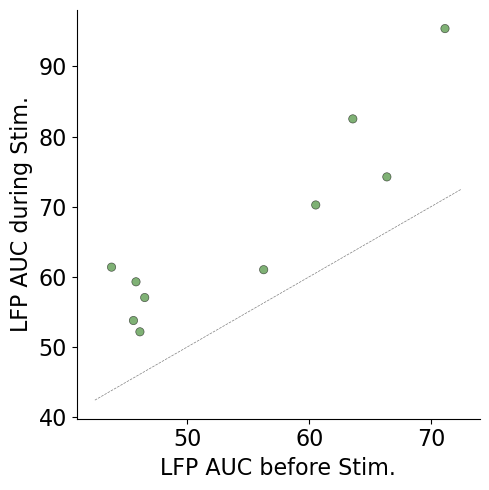

In [5]:

colors = {'#2a7e19', '#A8E5A0'}
colorborder='k'
figsize=[5,5]
## CONTRO TACTILE BAS vs STIM
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Tac') ]
DATA=DATA[(DATA['Side'] == 'Wcont') ]
DATA=DATA[(DATA['Line']== 'WT')]


DATA=DATA[['Date','MeanAUCBas','MeanAUCStim','ContrastAUC']]
DATAG=DATA.groupby(['Date']).mean()

df = pd.DataFrame(DATAG)

fig,ax = plt.subplots(1,1, figsize=(figsize))
sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=DATAG,hue='Date',palette=['#2a7e19'],edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)
ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('LFP AUC before Stim.')
ax.set_ylabel('LFP AUC during Stim.')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Figure1G_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)


wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim'])

print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))
toto=df['MeanAUCBas']<df['MeanAUCStim']
toto.value_counts()

## figure 1G

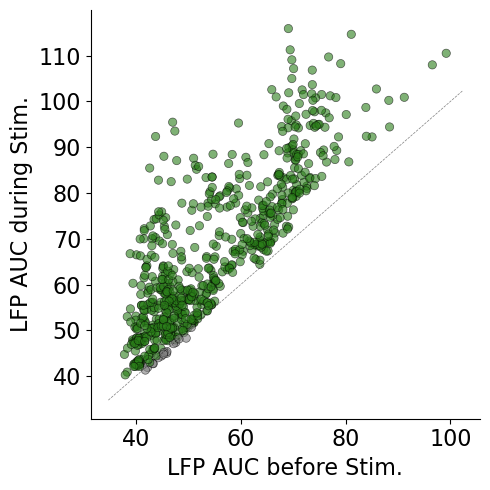

In [6]:

colors = {'#2a7e19', '#A8E5A0'}
colorborder='k'
figsize=[5,5]
## CONTRO TACTILE BAS vs STIM
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Tac') ]
DATA=DATA[(DATA['Side'] == 'Wcont') ]
DATA=DATA[(DATA['Line']== 'WT')]
df = pd.DataFrame(DATA)
fig,ax = plt.subplots(1,1, figsize=(figsize))
sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=df,hue='Response',palette=['gray','#2a7e19'],edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)
ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('LFP AUC before Stim.')
ax.set_ylabel('LFP AUC during Stim.')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Figure1G_LFP'

#plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
#plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

## Figure 1H

array([0.0078125])

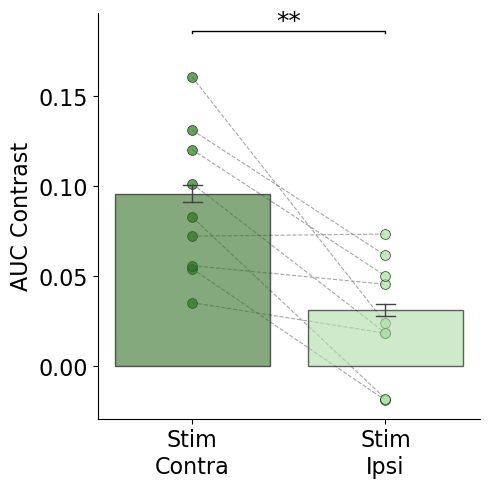

In [7]:
border_colors = 'k'
colors = ['#2a7e19','#A8E5A0']

##  TACTILE  STIM CONT vs IPSI  

DATA=DATACleaned

DATA=DATA[(DATA['Stim'] == 'Tac') ]
DATA=DATA[(DATA['Line']== 'WT')]
DATA=DATA[['Date','Side','ContrastAUC']]


DATAcont=DATA[(DATA['Side']== 'Wcont')]
cont=DATAcont[['Date','ContrastAUC']].groupby(['Date']).mean()
DATAipsi=DATA[(DATA['Side']== 'Wipsi')]
ipsi=DATAipsi[['Date','ContrastAUC']].groupby(['Date']).mean()
cont.drop(cont.index[5], inplace=True)

df = pd.DataFrame(DATA)

fig,ax = plt.subplots(1,1, figsize=(figsize))

sns.barplot(x='Side',y='ContrastAUC',data=df,ax=ax, palette=colors, capsize=0.1,
            err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('AUC Contrast')
ax.set_xticklabels(['Stim\nContra','Stim\nIpsi'])

x,x2=0,1
for i in range(len(cont)):
    plt.plot([x,x2],[cont['ContrastAUC'].values[i],ipsi['ContrastAUC'].values[i]] ,color='grey', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)
    sns.scatterplot(x=[x], y=[cont['ContrastAUC'].values[i]], color=colors[0], s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
    sns.scatterplot(x=[x2], y=[ipsi['ContrastAUC'].values[i]], color=colors[1], s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)

ax.set_xlabel('')
stats,p_value=wilcoxon(cont,ipsi)

# Fonction pour ajouter une barre de significativité
def add_Wilcox_sig_bar(x1, x2, y, p_val, height_offset=0.001, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

y_max=0.18
if p_value < 0.05:
    add_Wilcox_sig_bar(0, 1, y_max+0.005 , p_value)

plt.tight_layout()

titrefig='Figure1H_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

p_value

## Figure 2B

     NewFileName  ArrayId        Date Stim Therm   Side Line DayP  Anesthesie  \
114          115       12  2024.02.06  Thq  cool  Wcont   WT   P8           0   

     CSF  Deep                    FileName  \
114    0   407  allego_3__uid0206-14-15-34   

                                   CodeName  Valid  
114  Thq_cool_Wcont_WT_P8_F_4.7g_Buz32_Z407    1.0  


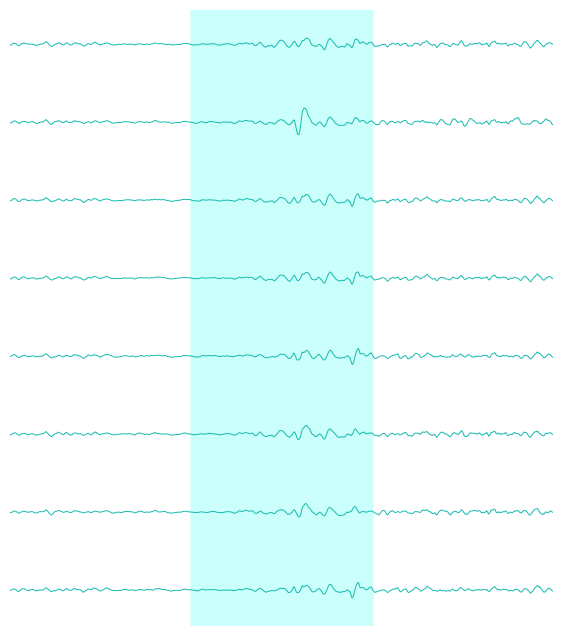

In [11]:
Newfilename=115


plotting_ind_channel=0

saving_dir=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA_LINUX_SHARED/DATA_UZ/figures'

MeanAUCBas=[]
MeanAUCStim=[]
Response=[]
dffile=DFDATA[DFDATA['NewFileName']==Newfilename]
print(dffile)

for ch in range(32):
   
    fileid=Newfilename-1
    lfp=LfpPop[fileid]
    lfpch=lfp[0][ch].T
    SizeLfp=np.shape(lfpch)
    derivative=np.diff(lfpch,axis=0)

    AUC=np.trapz(np.abs(derivative), axis=1)

    AUC_filt=savgol_filter(AUC, 51, 3)

    if (dffile['Stim'] == 'Tac').any:
        analysis_window=2000
    elif (dffile['Stim'] == 'Thq').any:
        if (dffile['Therm'] == 'cool').any:
            analysis_window=3900
        elif (dffile['Therm'] == 'hot').any:
            analysis_window=2200
    X=lfpch
    MeanAUCBas.append(np.mean(AUC_filt[0:analysis_window]))
    MeanAUCStim.append(np.mean(AUC_filt[10000:analysis_window+10000]))
    t_statistic, p_value = ttest_ind(AUC_filt[0:analysis_window],AUC_filt[10000:analysis_window+10000],alternative='less')
    if p_value<0.05:
        ResponseCh=1
    else:
        ResponseCh=0
    Response.append(ResponseCh)
lfp=LfpPop[fileid]

fig, ax = plt.subplots(1,1, figsize=(7,8))
start_time=8000
end_time=14000
stim_start=10000
stim_end=start_time+analysis_window

choffset=0
axid=1
ayid=1
for ch in mappingelectrode[0]:
    lfpch=lfp[0][ch].T
  
    ax. plot(savgol_filter(lfpch[:,2],101,3,axis=0)+choffset, color="#13bbaf", linewidth=0.7, alpha=1)
    #ax. plot(savgol_filter(np.mean(lfpch+choffset, axis=1),101,3,axis=0), color="#507b9c", linewidth=0.7, alpha=1)

    ax.set_xlabel('Time (ms)')
    ax.set_xticks([0, 5000, 10000, 15000, 20000])
    ax.set_xticklabels([-10, -5, 0, 5, 10])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Voltage (uV)', fontsize=12, color='k')
    ax.set_xlim(start_time,end_time)
    ax.axvspan(stim_start, stim_start+analysis_window, color='#cafffb', alpha=0.5, label='Cool stim', zorder=0)

    choffset=choffset-500


#fig.suptitle(dffile['Stim'].values[0]+' '+dffile['Therm'].values[0]+' '+dffile['Side'].values[0]+' '+' '+dffile['FileName'].values[0]+' '+'File '+str(Newfilename), fontsize=16)

ax.axis('off')




plt.savefig(os.path.join(saving_dir, 'Figure2B_LFP.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Figure2B_LFP.svg'), format='svg', dpi=300)

## Figure 4 B LFP

     NewFileName  ArrayId        Date Stim Therm   Side Line DayP  Anesthesie  \
147          148       15  2024.02.29  Thq  cool  Wcont   ML   P7           0   

     CSF  Deep                    FileName  \
147    0   407  allego_7__uid0229-15-01-23   

                                    CodeName  Valid  
147  Thq_cool_Wcont_ML2_P7_M_3,2g_Buz32_Z407    1.0  


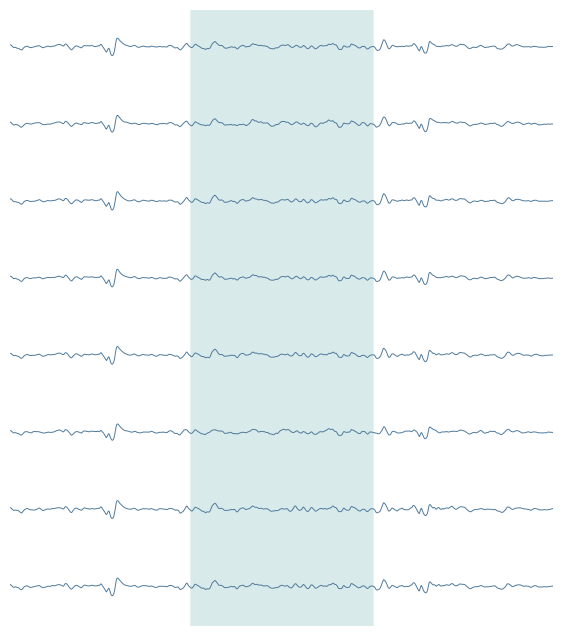

In [12]:
Newfilename=148

from scipy import stats
from matplotlib import rcParams
import warnings 

warnings.filterwarnings("ignore")

# Forcer l'utilisation du texte en tant que texte dans SVG
# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'path'

rcParams['font.family'] = 'DejaVu Sans'


colors = {'#2a7e19', '#A8E5A0'}
colorborder='k'

plt.rcParams.update({
    'axes.labelsize': 16,   # Taille des labels des axes
    'xtick.labelsize': 16,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 16,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 16,   # Taille de la police de la légende
    'axes.titlesize': 16,   # Taille du titre
    'axes.labelcolor': 'k',  # Couleur des labels
    'xtick.color': 'k',      # Couleur des ticks

})


plotting_ind_channel=0

saving_dir=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA_LINUX_SHARED/DATA_UZ/figures'

MeanAUCBas=[]
MeanAUCStim=[]
Response=[]
dffile=DFDATA[DFDATA['NewFileName']==Newfilename]
print(dffile)

for ch in range(32):
   
    fileid=Newfilename-1
    lfp=LfpPop[fileid]

    lfpch=lfp[0][ch].T

    SizeLfp=np.shape(lfpch)

    derivative=np.diff(lfpch,axis=0)

    AUC=np.trapz(np.abs(derivative), axis=1)

    AUC_filt=savgol_filter(AUC, 51, 3)

    if (dffile['Stim'] == 'Tac').any:
        analysis_window=2000
    elif (dffile['Stim'] == 'Thq').any:
        if (dffile['Therm'] == 'cool').any:
            analysis_window=3900
        elif (dffile['Therm'] == 'hot').any:
            analysis_window=2200

    X=lfpch

    MeanAUCBas.append(np.mean(AUC_filt[0:analysis_window]))
    MeanAUCStim.append(np.mean(AUC_filt[10000:analysis_window+10000]))

    t_statistic, p_value = stats.ttest_ind(AUC_filt[0:analysis_window],AUC_filt[10000:analysis_window+10000],alternative='less')

    if p_value<0.05:
        ResponseCh=1
    else:
        ResponseCh=0

    Response.append(ResponseCh)



lfp=LfpPop[fileid]


fig, ax = plt.subplots(1,1, figsize=(7,8))

start_time=8000
end_time=14000
stim_start=10000
stim_end=start_time+analysis_window

choffset=0
axid=1
ayid=1
for ch in mappingelectrode[2]:
    lfpch=lfp[0][ch].T
  
    #x. plot(savgol_filter(lfpch[:,3],101,3,axis=0)+choffset, color="#507b9c", linewidth=0.7, alpha=1)
    ax. plot(savgol_filter(np.mean(lfpch+choffset, axis=1),101,3,axis=0), color="#507b9c", linewidth=0.7, alpha=1)

    ax.set_xlabel('Time (ms)')
    ax.set_xticks([0, 5000, 10000, 15000, 20000])
    ax.set_xticklabels([-10, -5, 0, 5, 10])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Voltage (uV)', fontsize=12, color='k')
    ax.set_xlim(start_time,end_time)
    ax.axvspan(stim_start, stim_start+analysis_window, color='#D9EAEA', alpha=0.5, label='Cool stim', zorder=0)

    choffset=choffset-200


#fig.suptitle(dffile['Stim'].values[0]+' '+dffile['Therm'].values[0]+' '+dffile['Side'].values[0]+' '+' '+dffile['FileName'].values[0]+' '+'File '+str(Newfilename), fontsize=16)

ax.axis('off')




plt.savefig(os.path.join(saving_dir, 'Figure4B_LFP.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Figure4B_LFP.svg'), format='svg', dpi=300)

In [ ]:
DATA

,Date,Side,ContrastAUC
0,2024.01.31,Wcont,0.006841
1,2024.01.31,Wcont,0.002955
2,2024.01.31,Wcont,0.012448
3,2024.01.31,Wcont,0.008066
4,2024.01.31,Wcont,0.007023
...,...,...,...
27,2024.05.29,Wipsi,0.087781
28,2024.05.29,Wipsi,0.074816
29,2024.05.29,Wipsi,0.089854
30,2024.05.29,Wipsi,0.067475


## Figure 2D

     NewFileName  ArrayId        Date Stim Therm   Side Line DayP  Anesthesie  \
118          119       12  2024.02.06  Thq   hot  Wcont   WT   P8           0   

     CSF  Deep                    FileName  \
118    0   407  allego_7__uid0206-15-03-56   

                                  CodeName  Valid  
118  Thq_hot_Wcont_WT_P8_F_4.7g_Buz32_Z407    1.0  


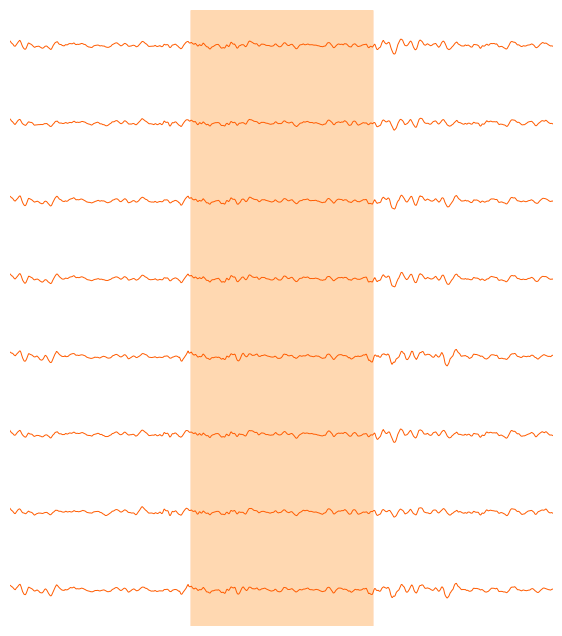

In [13]:
Newfilename=119

from scipy import stats
from matplotlib import rcParams
import warnings 

warnings.filterwarnings("ignore")

plotting_ind_channel=0
MeanAUCBas=[]
MeanAUCStim=[]
Response=[]
dffile=DFDATA[DFDATA['NewFileName']==Newfilename]
print(dffile)
for ch in range(32):
    fileid=Newfilename-1
    lfp=LfpPop[fileid]
    lfpch=lfp[0][ch].T
    SizeLfp=np.shape(lfpch)
    derivative=np.diff(lfpch,axis=0)
    AUC=np.trapz(np.abs(derivative), axis=1)
    AUC_filt=savgol_filter(AUC, 51, 3)
    if (dffile['Stim'] == 'Tac').any:
        analysis_window=2000
    elif (dffile['Stim'] == 'Thq').any:
        if (dffile['Therm'] == 'cool').any:
            analysis_window=3900
        elif (dffile['Therm'] == 'hot').any:
            analysis_window=2200
    X=lfpch
    MeanAUCBas.append(np.mean(AUC_filt[0:analysis_window]))
    MeanAUCStim.append(np.mean(AUC_filt[10000:analysis_window+10000]))
    t_statistic, p_value = stats.ttest_ind(AUC_filt[0:analysis_window],AUC_filt[10000:analysis_window+10000],alternative='less')
    if p_value<0.05:
        ResponseCh=1
    else:
        ResponseCh=0
    Response.append(ResponseCh)

lfp=LfpPop[fileid]

fig, ax = plt.subplots(1,1, figsize=(7,8))
start_time=8000
end_time=14000
stim_start=10000
stim_end=start_time+analysis_window
choffset=0
axid=1
ayid=1
for ch in mappingelectrode[0]:
    lfpch=lfp[0][ch].T
  
    ax. plot(savgol_filter(lfpch[:,7],101,3,axis=0)+choffset, color="#ff5b00", linewidth=0.7, alpha=1)
    #ax. plot(savgol_filter(np.mean(lfpch+choffset, axis=1),101,3,axis=0), color="#507b9c", linewidth=0.7, alpha=1)
    ax.set_xlabel('Time (ms)')
    ax.set_xticks([0, 5000, 10000, 15000, 20000])
    ax.set_xticklabels([-10, -5, 0, 5, 10])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Voltage (uV)', fontsize=12, color='k')
    ax.set_xlim(start_time,end_time)
    ax.axvspan(stim_start, stim_start+analysis_window, color='#ffd8b1', alpha=0.5, label='Cool stim', zorder=0)
    choffset=choffset-500
 #  fig.suptitle(dffile['Stim'].values[0]+' '+dffile['Therm'].values[0]+' '+dffile['Side'].values[0]+' '+' '+dffile['FileName'].values[0]+' '+'File '+str(Newfilename), fontsize=16)
ax.axis('off')

plt.savefig(os.path.join(saving_dir, 'Figure2D_LFP.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Figure2D_LFP.svg'), format='svg', dpi=300)

## figure 4D

     NewFileName  ArrayId        Date Stim Therm   Side Line DayP  Anesthesie  \
148          149       15  2024.02.29  Thq   hot  Wcont   ML   P7           0   

     CSF  Deep                    FileName  \
148    0   407  allego_8__uid0229-15-13-13   

                                   CodeName  Valid  
148  Thq_hot_Wcont_ML2_P7_M_3,2g_Buz32_Z407    1.0  


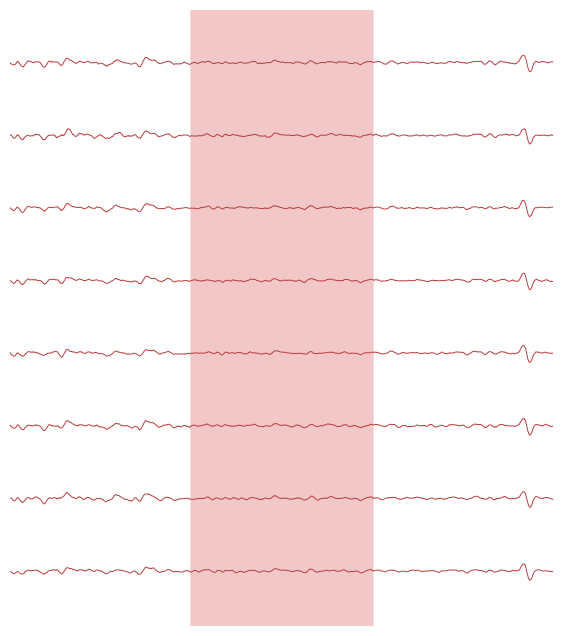

In [14]:
Newfilename=149

from scipy import stats
from matplotlib import rcParams
import warnings 

warnings.filterwarnings("ignore")

plotting_ind_channel=0
MeanAUCBas=[]
MeanAUCStim=[]
Response=[]
dffile=DFDATA[DFDATA['NewFileName']==Newfilename]
print(dffile)
for ch in range(32):
    fileid=Newfilename-1
    lfp=LfpPop[fileid]
    lfpch=lfp[0][ch].T
    SizeLfp=np.shape(lfpch)
    derivative=np.diff(lfpch,axis=0)
    AUC=np.trapz(np.abs(derivative), axis=1)
    AUC_filt=savgol_filter(AUC, 51, 3)
    if (dffile['Stim'] == 'Tac').any:
        analysis_window=2000
    elif (dffile['Stim'] == 'Thq').any:
        if (dffile['Therm'] == 'cool').any:
            analysis_window=3900
        elif (dffile['Therm'] == 'hot').any:
            analysis_window=2200
    X=lfpch
    MeanAUCBas.append(np.mean(AUC_filt[0:analysis_window]))
    MeanAUCStim.append(np.mean(AUC_filt[10000:analysis_window+10000]))
    t_statistic, p_value = stats.ttest_ind(AUC_filt[0:analysis_window],AUC_filt[10000:analysis_window+10000],alternative='less')
    if p_value<0.05:
        ResponseCh=1
    else:
        ResponseCh=0
    Response.append(ResponseCh)

lfp=LfpPop[fileid]

fig, ax = plt.subplots(1,1, figsize=(7,8))
start_time=8000
end_time=14000
stim_start=10000
stim_end=start_time+analysis_window
choffset=0
axid=1
ayid=1
for ch in mappingelectrode[0]:
    lfpch=lfp[0][ch].T
  
    ax. plot(savgol_filter(lfpch[:,4],101,3,axis=0)+choffset, color="#bb3f3f", linewidth=0.7, alpha=1)
    #ax. plot(savgol_filter(np.mean(lfpch+choffset, axis=1),101,3,axis=0), color="#507b9c", linewidth=0.7, alpha=1)
    ax.set_xlabel('Time (ms)')
    ax.set_xticks([0, 5000, 10000, 15000, 20000])
    ax.set_xticklabels([-10, -5, 0, 5, 10])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Voltage (uV)', fontsize=12, color='k')
    ax.set_xlim(start_time,end_time)
    ax.axvspan(stim_start, stim_start+analysis_window, color='#F2C7C7', alpha=0.5, label='Cool stim', zorder=0)
    choffset=choffset-200
 #  fig.suptitle(dffile['Stim'].values[0]+' '+dffile['Therm'].values[0]+' '+dffile['Side'].values[0]+' '+' '+dffile['FileName'].values[0]+' '+'File '+str(Newfilename), fontsize=16)
ax.axis('off')

plt.savefig(os.path.join(saving_dir, 'Figure4D_LFP.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Figure4D_LFP.svg'), format='svg', dpi=300)

## Figure 2K

WilcoxonResult(statistic=0.0, pvalue=0.001953125)


True    10
Name: count, dtype: int64

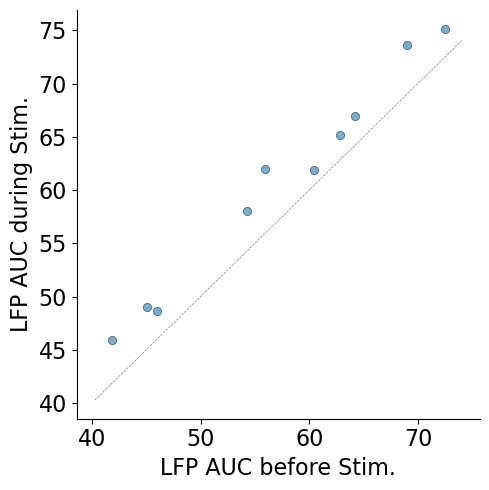

In [15]:
colors = {'#2a7e19', '#A8E5A0'}
colorborder='k'
figsize=[5,5]
## CONTRO TACTILE BAS vs STIM
DATA=DATACleaned
DATA=DATA[(DATA['Response'] == 1) ]

DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Therm'] == 'cool') ]
DATA=DATA[(DATA['Side'] == 'Wcont') ]
DATA=DATA[(DATA['Line']== 'WT')]

DATA=DATA[['Date','MeanAUCBas','MeanAUCStim','ContrastAUC']]
DATAG=DATA.groupby(['Date']).mean()


df = pd.DataFrame(DATAG)

fig,ax = plt.subplots(1,1, figsize=(figsize))
sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=df,palette=['gray','#13bbaf'],edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)
ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('LFP AUC before Stim.')
ax.set_ylabel('LFP AUC during Stim.')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Figur2K_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim'])

print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))
toto=df['MeanAUCBas']<df['MeanAUCStim']
toto.value_counts()

## Figure 2L

WilcoxonResult(statistic=23.0, pvalue=0.6953125)


True     5
False    5
Name: count, dtype: int64

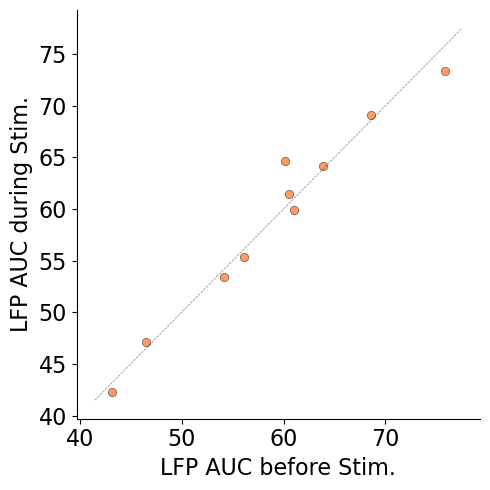

In [16]:
colorborder='k'
figsize=[5,5]
## CONTRO TACTILE BAS vs STIM
DATA=DATACleaned

DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Therm'] == 'hot') ]
DATA=DATA[(DATA['Side'] == 'Wcont') ]
DATA=DATA[(DATA['Line']== 'WT')]

DATA=DATA[['Date','MeanAUCBas','MeanAUCStim','ContrastAUC']]
DATAG=DATA.groupby(['Date']).mean()


df = pd.DataFrame(DATAG)

fig,ax = plt.subplots(1,1, figsize=(figsize))
sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=DATAG,color='#ff5b00',edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)
ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('LFP AUC before Stim.')
ax.set_ylabel('LFP AUC during Stim.')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Figur2L_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim'])

print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))
toto=DATAG['MeanAUCBas']<DATAG['MeanAUCStim']
toto.value_counts()

## Figure 4J

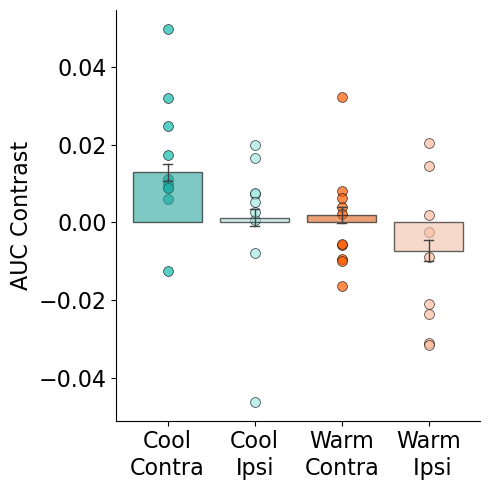

In [17]:
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Thq')]
DATA=DATA[(DATA['Line']== 'WT')]


border_colors = 'k'
colors = {'Cool_Cont': '#13bbaf', 'Cool_Ipsi': '#A6E7E3', 
          'Warm_Cont': '#ff5b00', 'Warm_Ipsi': '#FFBC9E'}


df1=DATA[(DATA['Therm'] == 'cool') & (DATA['Side'] == 'Wcont')]
df1['condition'] = df1['Therm'] + '_' + df1['Side']
df2=DATA[(DATA['Therm'] == 'cool') & (DATA['Side'] == 'Wipsi')]
df2['condition'] = df2['Therm'] + '_' + df2['Side']
df3=DATA[(DATA['Therm'] == 'hot') & (DATA['Side'] == 'Wcont')]
df3['condition'] = df3['Therm'] + '_' + df3['Side']
df4=DATA[(DATA['Therm'] == 'hot') &(DATA['Side'] == 'Wipsi')]
df4['condition'] = df4['Therm'] + '_' + df4['Side']
df = pd.concat([df1, df2, df3, df4])

DF=df[['Date','condition','MeanAUCBas','MeanAUCStim','ContrastAUC']]
DF1=DF[(DF['condition'] == 'cool_Wcont') ]
DF1.drop(columns=['condition'], inplace=True)
DF1=DF1.groupby(['Date']).mean()
DF1['condition']='cool_Wcont'

DF2=DF[(DF['condition'] == 'cool_Wipsi') ]
DF2.drop(columns=['condition'], inplace=True)
DF2=DF2.groupby(['Date']).mean()
DF2['condition']='cool_Wipsi'

DF3=DF[(DF['condition'] == 'hot_Wcont') ]
DF3.drop(columns=['condition'], inplace=True)
DF3=DF3.groupby(['Date']).mean()
DF3['condition']='hot_Wcont'

DF4=DF[(DF['condition'] == 'hot_Wipsi') ]
DF4.drop(columns=['condition'], inplace=True)
DF4=DF4.groupby(['Date']).mean()
DF4['condition']='hot_Wipsi'

DF=pd.concat([DF1,DF2,DF3,DF4])



colors = {'cool_Wcont': '#13bbaf', 'cool_Wipsi': '#A6E7E3', 
          'hot_Wcont': '#ff5b00', 'hot_Wipsi': '#FFBC9E'}
border_colors = 'k'




# Plot
fig,ax=plt.subplots(1,1, figsize=(5,5))
# Barplot avec erreur SEM
sns.barplot(ax=ax,x='condition', y='ContrastAUC',hue='condition' ,data=df, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)
ax.set_xticklabels(['Cool\nContra','Cool\nIpsi','Warm\nContra','Warm\n Ipsi'], multialignment='center')


x,x2,x3,x4=0,1,2,3

for i in range(len(DF1)):
    sns.scatterplot(x=x, y=[DF1["ContrastAUC"].values[i]], color='#13bbaf', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
for i in range(len(DF2)):
    sns.scatterplot(x=x2, y=[DF2["ContrastAUC"].values[i]], color='#A6E7E3', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
for i in range(len(DF3)):
    sns.scatterplot(x=x3, y=[DF3["ContrastAUC"].values[i]], color='#ff5b00', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
for i in range(len(DF4)):
    sns.scatterplot(x=x4, y=[DF4["ContrastAUC"].values[i]], color='#FFBC9E', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
    

ax.set_ylabel('AUC Contrast')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('')

titrefig='Figur4J_LFP'

plt.tight_layout()

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

# df.to_excel(os.path.join(saving_dir, 'DATA_LFP_4cond_WT_Therm.xlsx'), index=False)




In [18]:
dfstats=[]
dfstats.append(DF1["ContrastAUC"].values)
dfstats.append(DF2["ContrastAUC"].values)
dfstats.append(DF3["ContrastAUC"].values)
dfstats.append(DF4["ContrastAUC"].values)

DataStats_figure_2J=dfstats

np.savez_compressed(os.path.join(saving_dir, 'DataStats_figure_2J.npz'), *DataStats_figure_2J)



In [19]:
data=np.load(os.path.join(saving_dir, 'DataStats_figure_2J.npz'), allow_pickle=True)
data['arr_0']
data['arr_1']
data['arr_2']
data['arr_3']

array([ 0.01467368, -0.00895501,  0.02058058,  0.00191699, -0.02367031,
       -0.03109445, -0.03157645, -0.00241544, -0.02112404], dtype=float32)

## Figure 3I

               ContrastAUC
Date                      
2024.01.30_M2     0.073051
2024.02.05_M1     0.047078
2024.02.22        0.041907
2024.02.29        0.138130
2024.04.09        0.147712
               ContrastAUC
Date                      
2024.01.30_M2    -0.022683
2024.02.05_M1     0.130843
2024.02.22       -0.007297
2024.02.29        0.145590
2024.04.09        0.085999


array([0.625])

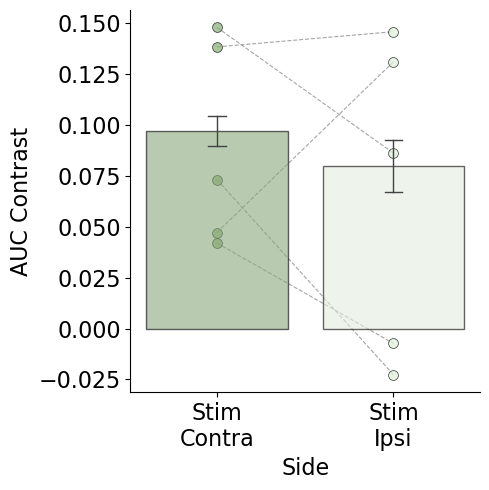

In [20]:
border_colors = 'k'
colors = ['#87ae73','#e2f0dc']

##  TACTILE  STIM CONT vs IPSI  

DATA=DATACleaned

DATA=DATA[(DATA['Stim'] == 'Tac') ]
DATA=DATA[(DATA['Line']== 'ML')]
DATA=DATA[['Date','Side','ContrastAUC']]


DATAcont=DATA[(DATA['Side']== 'Wcont')]
cont=DATAcont[['Date','ContrastAUC']].groupby(['Date']).mean()
DATAipsi=DATA[(DATA['Side']== 'Wipsi')]
ipsi=DATAipsi[['Date','ContrastAUC']].groupby(['Date']).mean()

df = pd.DataFrame(DATA)

fig,ax = plt.subplots(1,1, figsize=(figsize))

#sns.stripplot(x=df['Side'],y=df['ContrastAUC'],ax=ax,palette='gray',alpha=0.1,edgecolor=colorborder,linewidth=0.5)
sns.barplot(x=df['Side'],y=df['ContrastAUC'],ax=ax, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('AUC Contrast')
ax.set_xticklabels(['Stim\nContra','Stim\nIpsi'])


x,x2=0,1
for i in range(len(cont)):
    plt.plot([x,x2],[cont['ContrastAUC'].values[i],ipsi['ContrastAUC'].values[i]] ,color='grey', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)
    sns.scatterplot(x=[x], y=[cont['ContrastAUC'].values[i]], color=colors[0], s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
    sns.scatterplot(x=[x2], y=[ipsi['ContrastAUC'].values[i]], color=colors[1], s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)

# stat, p_value = mannwhitneyu(df[df['Side']=='Wcont']['ContrastAUC'], df[df['Side']=='Wipsi']['ContrastAUC'])
stats, p_value=wilcoxon(cont,ipsi)

# Fonction pour ajouter une barre de significativité
def add_Wilcox_sig_bar(x1, x2, y, p_val, height_offset=0.001, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

y_max=0.1
if p_value < 0.05:
    add_Wilcox_sig_bar(0, 1, y_max+0.01, p_value)

plt.tight_layout()

titrefig='Figure3I_Tac_ML_ContVsIpsi_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)
print(cont)

print(ipsi)
p_value

## Figure 3J

WilcoxonResult(statistic=0.0, pvalue=0.0625)


True    5
Name: count, dtype: int64

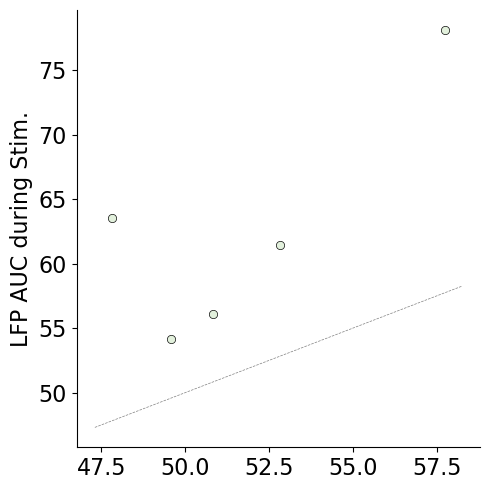

In [21]:
colorborder='k'
figsize=[5,5]
## CONTRO TACTILE BAS vs STIM
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Tac') ]
DATA=DATA[(DATA['Side'] == 'Wcont') ]
DATA=DATA[(DATA['Line']== 'ML')]


DATA=DATA[['Date','MeanAUCBas','MeanAUCStim','ContrastAUC']]
DATAG=DATA.groupby(['Date']).mean()


df = pd.DataFrame(DATAG)
fig,ax = plt.subplots(1,1, figsize=(figsize))
sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=DATAG,color='#e2f0dc',edgecolor=colorborder, ax=ax,legend=False)
ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('LFP AUC before Stim.')
ax.set_ylabel('LFP AUC during Stim.')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('')

plt.tight_layout()

titrefig='Figure3J_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim'])


print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))
toto=DATAG['MeanAUCBas']<DATAG['MeanAUCStim']
toto.value_counts()

## Figure 3K

MannwhitneyuResult(statistic=82001.0, pvalue=0.2713134452028386)

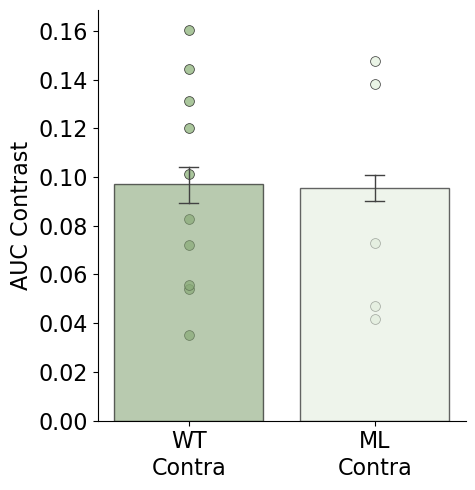

In [22]:
border_colors = 'k'
colors = ['#87ae73','#e2f0dc']

##  TACTILE  ML vs WT 

DATA=DATACleaned

DATA=DATA[(DATA['Stim'] == 'Tac') ]
DATA=DATA[(DATA['Side']== 'Wcont')]


DATAwt=DATA[(DATA['Line']== 'WT')]
wt=DATAwt[['Date','ContrastAUC']].groupby(['Date']).mean()
DATAml=DATA[(DATA['Line']== 'ML')]
ml=DATAml[['Date','ContrastAUC']].groupby(['Date']).mean()

df = pd.DataFrame(DATA)

fig,ax = plt.subplots(1,1, figsize=(figsize))

#sns.stripplot(x=df['Side'],y=df['ContrastAUC'],ax=ax,palette='gray',alpha=0.1,edgecolor=colorborder,linewidth=0.5)
sns.barplot(x=df['Line'],y=df['ContrastAUC'],ax=ax, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('AUC Contrast')
ax.set_xticklabels(['WT\nContra','ML\nContra'])
ax.set_xlabel('')



x,x2=0,1
for i in range(len(ml)):
    sns.scatterplot(x=[x2], y=[ml['ContrastAUC'].values[i]], color=colors[1], s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
for i in range(len(wt)):
    sns.scatterplot(x=[x], y=[wt['ContrastAUC'].values[i]], color=colors[0], s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)

stat, p_value = mannwhitneyu(df[df['Line']=='WT']['ContrastAUC'], df[df['Line']=='ML']['ContrastAUC'])


# Fonction pour ajouter une barre de significativité
def add_Wilcox_sig_bar(x1, x2, y, p_val, height_offset=0.001, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

y_max=0.1
if p_value < 0.05:
    add_Wilcox_sig_bar(0, 1, y_max+0.01, p_value)

plt.tight_layout()

titrefig='Figure3K_Tac_MLVsWt_Cont_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

mannwhitneyu(df[df['Line']=='WT']['ContrastAUC'], df[df['Line']=='ML']['ContrastAUC'])

## Figure 4N

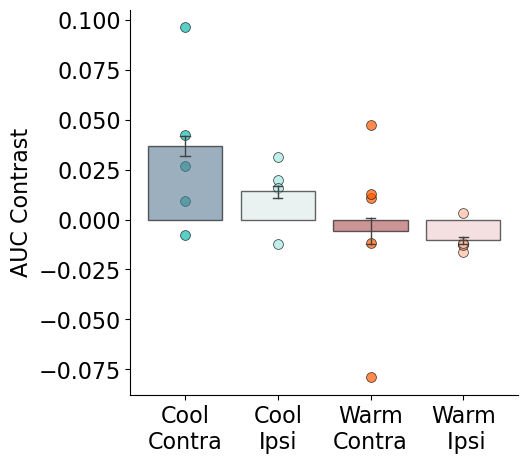

In [23]:


border_colors = 'k'

colors= {'cool_Wcont': '#507b9c', 'cool_Wipsi': '#D9EAEA', 
          'hot_Wcont': '#bb3f3f', 'hot_Wipsi': '#F2C7C7'}

DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Thq')]
DATA=DATA[(DATA['Line']== 'ML')]

df1=DATA[(DATA['Therm'] == 'cool') & (DATA['Side'] == 'Wcont')]
df1['condition'] = df1['Therm'] + '_' + df1['Side']
df2=DATA[(DATA['Therm'] == 'cool') & (DATA['Side'] == 'Wipsi')]
df2['condition'] = df2['Therm'] + '_' + df2['Side']
df3=DATA[(DATA['Therm'] == 'hot') & (DATA['Side'] == 'Wcont')]
df3['condition'] = df3['Therm'] + '_' + df3['Side']
df4=DATA[(DATA['Therm'] == 'hot') &(DATA['Side'] == 'Wipsi')]
df4['condition'] = df4['Therm'] + '_' + df4['Side']

df = pd.concat([df1, df2, df3, df4])



DF=df[['Date','condition','MeanAUCBas','MeanAUCStim','ContrastAUC']]
DF1=DF[(DF['condition'] == 'cool_Wcont') ]
DF1.drop(columns=['condition'], inplace=True)
DF1=DF1.groupby(['Date']).mean()
DF1['condition']='cool_Wcont'

DF2=DF[(DF['condition'] == 'cool_Wipsi') ]
DF2.drop(columns=['condition'], inplace=True)
DF2=DF2.groupby(['Date']).mean()
DF2['condition']='cool_Wipsi'

DF3=DF[(DF['condition'] == 'hot_Wcont') ]
DF3.drop(columns=['condition'], inplace=True)
DF3=DF3.groupby(['Date']).mean()
DF3['condition']='hot_Wcont'

DF4=DF[(DF['condition'] == 'hot_Wipsi') ]
DF4.drop(columns=['condition'], inplace=True)
DF4=DF4.groupby(['Date']).mean()
DF4['condition']='hot_Wipsi'

DF=pd.concat([DF1,DF2,DF3,DF4])

colors= {'cool_Wcont': '#507b9c', 'cool_Wipsi': '#D9EAEA', 
          'hot_Wcont': '#bb3f3f', 'hot_Wipsi': '#F2C7C7'}
border_colors = 'k'

# Plot
fig,ax=plt.subplots(1,1, figsize=(5,5))
# Barplot avec erreur SEM
sns.barplot(ax=ax,x='condition', y='ContrastAUC',hue='condition' ,data=df, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)
ax.set_xticklabels(['Cool\nContra','Cool\nIpsi','Warm\nContra','Warm\n Ipsi'], multialignment='center')
ax.set_ylabel('AUC Contrast')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('')


x,x2,x3,x4=0,1,2,3

for i in range(len(DF1)):
    sns.scatterplot(x=x, y=[DF1["ContrastAUC"].values[i]], color='#13bbaf', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
for i in range(len(DF2)):
    sns.scatterplot(x=x2, y=[DF2["ContrastAUC"].values[i]], color='#A6E7E3', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
for i in range(len(DF3)):
    sns.scatterplot(x=x3, y=[DF3["ContrastAUC"].values[i]], color='#ff5b00', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
for i in range(len(DF4)):
    sns.scatterplot(x=x4, y=[DF4["ContrastAUC"].values[i]], color='#FFBC9E', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
    

titrefig='Figur4N_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

# df.to_excel(os.path.join(saving_dir, 'DATA_LFP_4cond_WT_Therm.xlsx'), index=False)

In [24]:
dfstats=[]
dfstats.append(DF1["ContrastAUC"].values)
dfstats.append(DF2["ContrastAUC"].values)
dfstats.append(DF3["ContrastAUC"].values)
dfstats.append(DF4["ContrastAUC"].values)

np.savez_compressed(os.path.join(saving_dir, 'DataStats_figure_4N.npz'), *dfstats)

## Figure 4O

WilcoxonResult(statistic=1.0, pvalue=0.125)


True     4
False    1
Name: count, dtype: int64

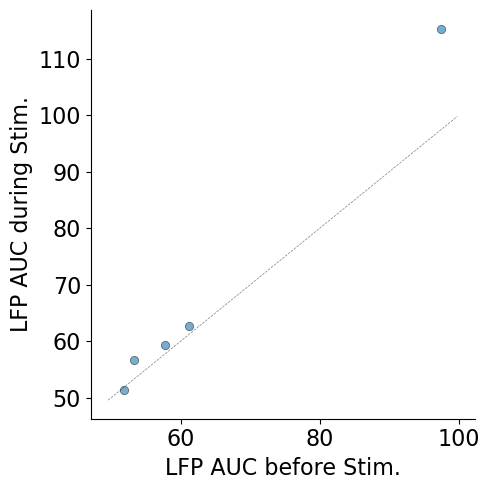

In [25]:
colorborder='k'
figsize=[5,5]
## CONTRO TACTILE BAS vs STIM
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Therm'] == 'cool') ]
DATA=DATA[(DATA['Line']== 'ML')]

DATA=DATA[['Date','MeanAUCBas','MeanAUCStim','ContrastAUC']]
DATAG=DATA.groupby(['Date']).mean()

df = pd.DataFrame(DATA)
fig,ax = plt.subplots(1,1, figsize=(figsize))
sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=DATAG,palette=['gray','#507b9c'],edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)
ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('LFP AUC before Stim.')
ax.set_ylabel('LFP AUC during Stim.')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Figure4O_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim'])

print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))
toto=DATAG['MeanAUCBas']<DATAG['MeanAUCStim']
toto.value_counts()

## Figure 4P

WilcoxonResult(statistic=6.0, pvalue=0.8125)


False    3
True     2
Name: count, dtype: int64

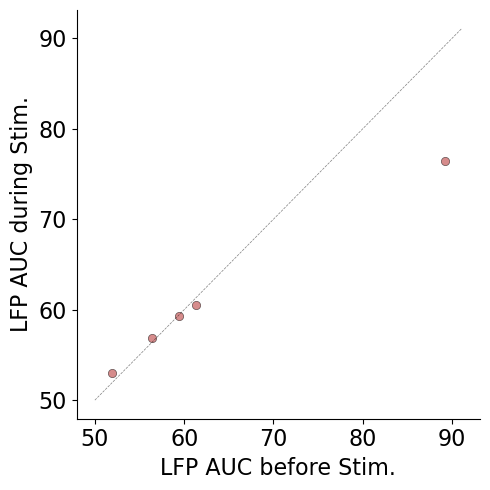

In [26]:
colorborder='k'
figsize=[5,5]
## CONTRO TACTILE BAS vs STIM
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Therm'] == 'hot') ]
DATA=DATA[(DATA['Line']== 'ML')]

DATA=DATA[['Date','MeanAUCBas','MeanAUCStim','ContrastAUC']]
DATAG=DATA.groupby(['Date']).mean()

df = pd.DataFrame(DATA)
fig,ax = plt.subplots(1,1, figsize=(figsize))
sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=DATAG,color='#bb3f3f',edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)
ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('LFP AUC before Stim.')
ax.set_ylabel('LFP AUC during Stim.')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Figure4P_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim'])

print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))
toto=DATAG['MeanAUCBas']<DATAG['MeanAUCStim']
toto.value_counts()

## Figure 4Q

2.4075685714701225e-14

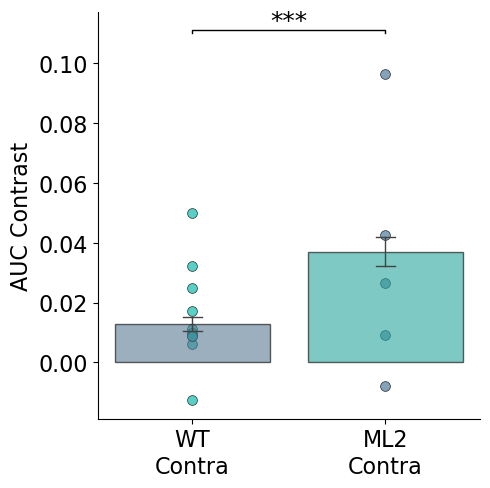

In [27]:
border_colors = 'k'
colors = { '#13bbaf', '#507b9c'}

##  TACTILE  STIM CONT vs IPSI  

DATA=DATACleaned

DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Side']== 'Wcont')]
DATA=DATA[(DATA['Therm'] == 'cool') ]


DATAwt=DATA[(DATA['Line']== 'WT')]
wt=DATAwt[['Date','ContrastAUC']].groupby(['Date']).mean()
DATAml=DATA[(DATA['Line']== 'ML')]
ml=DATAml[['Date','ContrastAUC']].groupby(['Date']).mean()



df = pd.DataFrame(DATA)

fig,ax = plt.subplots(1,1, figsize=(figsize))

#sns.stripplot(x=df['Side'],y=df['ContrastAUC'],ax=ax,palette='gray',alpha=0.1,edgecolor=colorborder,linewidth=0.5)
sns.barplot(x=df['Line'],y=df['ContrastAUC'],ax=ax, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6,
            edgecolor=border_colors,order=['WT','ML'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('AUC Contrast')
ax.set_xticklabels(['WT\nContra','ML2\nContra'])
ax.set_xlabel('')


x,x2=0,1
for i in range(len(ml)):
    sns.scatterplot(x=[x2], y=[ml['ContrastAUC'].values[i]], color='#507b9c', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
for i in range(len(wt)):
    sns.scatterplot(x=[x], y=[wt['ContrastAUC'].values[i]], color='#13bbaf', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)


stat, p_value = mannwhitneyu(df[df['Line']=='WT']['ContrastAUC'], df[df['Line']=='ML']['ContrastAUC'])


# Fonction pour ajouter une barre de significativité
def add_Wilcox_sig_bar(x1, x2, y, p_val, height_offset=0.001, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

y_max=0.1
if p_value < 0.05:
    add_Wilcox_sig_bar(0, 1, y_max+0.01, p_value)

plt.tight_layout()

titrefig='Figure4Q_Cool_WTvsML_Cont_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

p_value

## Figure 4R

0.46023917479697873

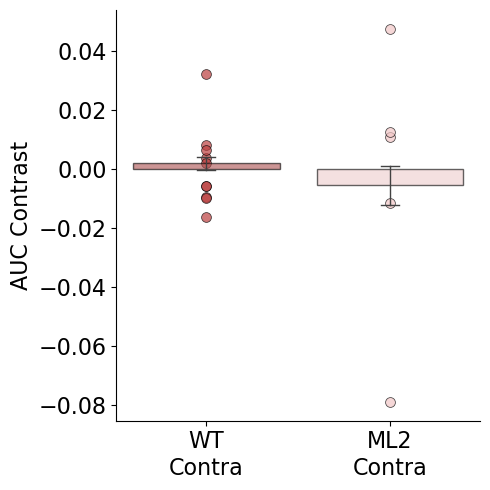

In [28]:
border_colors = 'k'
colors = ['#bb3f3f', '#F2C7C7']
##  TACTILE  STIM CONT vs IPSI  bb3f3f
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Side']== 'Wcont')]
DATA=DATA[(DATA['Therm'] == 'hot') ]


DATAwt=DATA[(DATA['Line']== 'WT')]
wt=DATAwt[['Date','ContrastAUC']].groupby(['Date']).mean()
DATAml=DATA[(DATA['Line']== 'ML')]
ml=DATAml[['Date','ContrastAUC']].groupby(['Date']).mean()

df = pd.DataFrame(DATA)
fig,ax = plt.subplots(1,1, figsize=(figsize))
#sns.stripplot(x=df['Side'],y=df['ContrastAUC'],ax=ax,palette='gray',alpha=0.1,edgecolor=colorborder,linewidth=0.5)
sns.barplot(x=df['Line'],y=df['ContrastAUC'],ax=ax, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6,
            edgecolor=border_colors,order=['WT','ML'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('AUC Contrast')
ax.set_xlabel('')
ax.set_xticklabels(['WT\nContra','ML2\nContra'])


x,x2=0,1
for i in range(len(ml)):
    sns.scatterplot(x=[x2], y=[ml['ContrastAUC'].values[i]], color='#F2C7C7', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)
for i in range(len(wt)):
    sns.scatterplot(x=[x], y=[wt['ContrastAUC'].values[i]], color='#bb3f3f', s=50, legend=None, marker='o', edgecolor='k', alpha=0.7, zorder=0)


stat, p_value = mannwhitneyu(df[df['Line']=='WT']['ContrastAUC'], df[df['Line']=='ML']['ContrastAUC'])
# Fonction pour ajouter une barre de significativité
def add_Wilcox_sig_bar(x1, x2, y, p_val, height_offset=0.001, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return
    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

y_max=0.1
if p_value < 0.05:
    add_Wilcox_sig_bar(0, 1, y_max+0.01, p_value)
plt.tight_layout()

titrefig='Figure4R_Hot_WTvsML_Cont_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

p_value